# CascadeWatch — Exploratory Data Analysis
**Project:** ML-Powered Crypto Liquidation Cascade Predictor  
**Author:** Priyanka Kanojia  
**Data:** BTC, ETH, SOL — Apr 2025 to Mar 2026 (24,123 hourly rows)  
**Cascade events labeled:** 56 across 3 symbols  

## Key findings
- RSI begins declining ~2 hours before cascade onset on average
- Volume spikes are coincident with cascades, not leading indicators
- Consecutive positive funding hours show 10x elevation in pre-cascade windows
- Linear correlation is near-zero for all features vs pre_cascade — confirming non-linear ML approach is correct

In [1]:
# Cell 1: Imports and setup
# Every library we need for the entire notebook loaded upfront.
# pandas = data manipulation
# numpy = math operations
# matplotlib + seaborn = plotting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plot style — dark theme looks great in portfolio screenshots
plt.style.use("dark_background")
sns.set_palette("husl")

# Make plots larger and sharper
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

print("✅ Libraries loaded successfully")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

✅ Libraries loaded successfully
pandas version: 2.3.3
numpy version: 2.4.3


In [3]:
# Cell 2: Set working directory + load data
import os

# Move up one level from notebooks/ to the project root
# __file__ doesn't exist in notebooks, so we use os.getcwd() and go up
os.chdir("..")

# Confirm we're now in the right place
print(f"Working directory: {os.getcwd()}")

# Now load the file — path is now relative to project root
df = pd.read_parquet("data/features/features_labeled.parquet")

normal = df[df["pre_cascade"] == 0]
danger = df[df["pre_cascade"] == 1]

print(f"Total rows:        {len(df):,}")
print(f"Symbols:           {df['symbol'].unique()}")
print(f"Date range:        {df.index.min().date()} → {df.index.max().date()}")
print(f"Normal rows:       {len(normal):,}")
print(f"Pre-cascade rows:  {len(danger):,}")
print(f"Class imbalance:   {len(danger)/len(df)*100:.2f}% dangerous")
print(f"\nColumns available:")
print([c for c in df.columns])

Working directory: /Users/priyankakanojia/projects/cascade-predictor
Total rows:        24,123
Symbols:           ['BTC' 'SOL' 'ETH']
Date range:        2025-04-26 → 2026-03-27
Normal rows:       23,899
Pre-cascade rows:  224
Class imbalance:   0.93% dangerous

Columns available:
['open', 'high', 'low', 'close', 'volume_base', 'volume_quote', 'fundingRate', 'premium', 'returns_1h', 'returns_4h', 'volatility_24h', 'volatility_4h', 'volatility_compression', 'volume_ma_24h', 'volume_ratio', 'funding_rate', 'funding_zscore', 'funding_acceleration', 'consecutive_positive_funding', 'funding_max_24h', 'roc_4h', 'rsi_14', 'high_24h', 'low_24h', 'price_position', 'ma_168h', 'price_vs_ma', 'symbol', 'future_return_4h', 'cascade_event', 'pre_cascade', 'hours_to_cascade']


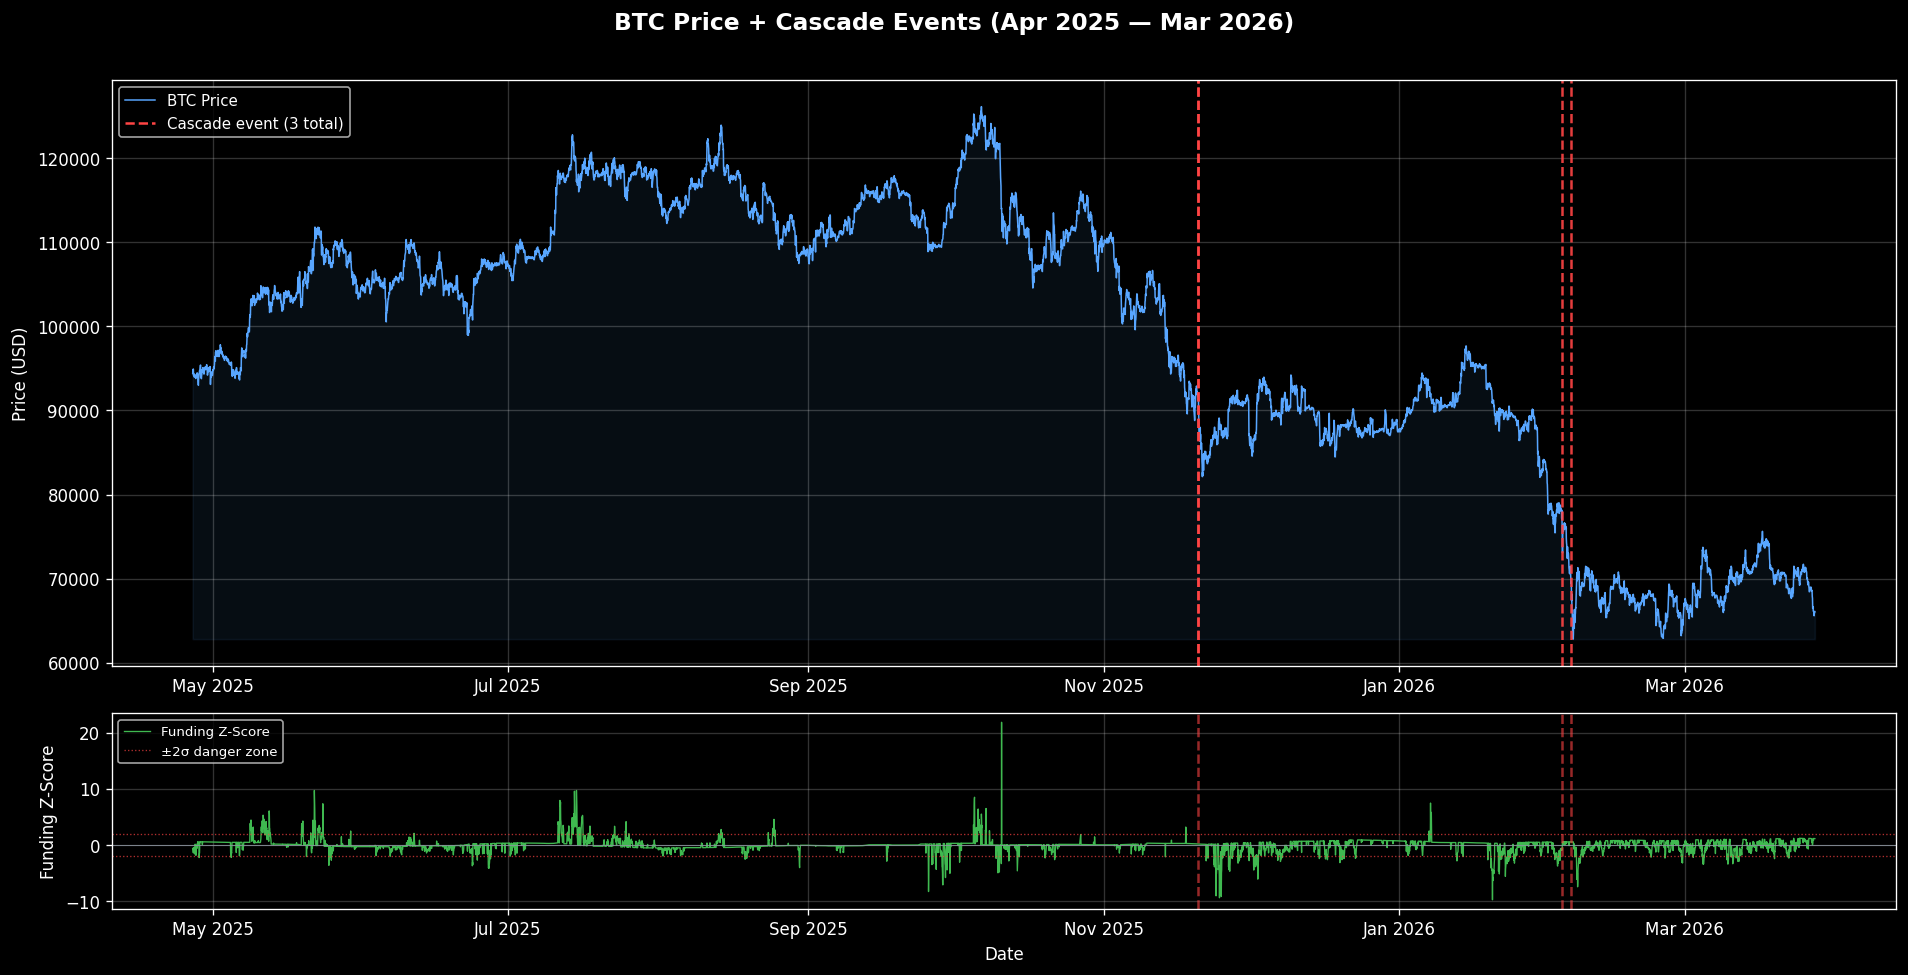

✅ Saved to docs/plot_btc_timeline.png
   BTC cascade events detected: 3
   Dates: ['2025-11-20 14:00', '2026-02-03 14:00', '2026-02-05 13:00']


In [4]:
# Cell 3: BTC price timeline with cascade events marked
# CONCEPT: This plot answers "did anything actually happen on those dates?"
# Red dashed lines = confirmed cascade events our labeler detected.
# If the red lines align with obvious price drops, our labeling is correct.

import matplotlib.dates as mdates

btc = df[df["symbol"] == "BTC"].copy()
btc_cascades = btc[btc["cascade_event"] == 1]
btc_pre = btc[btc["pre_cascade"] == 1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8),
                                gridspec_kw={"height_ratios": [3, 1]})
fig.suptitle("BTC Price + Cascade Events (Apr 2025 — Mar 2026)",
             fontsize=14, fontweight="bold", y=1.01)

# --- Top panel: price chart ---
ax1.plot(btc.index, btc["close"], color="#58a6ff", linewidth=0.9, label="BTC Price")
ax1.fill_between(btc.index, btc["close"], btc["close"].min(),
                 alpha=0.08, color="#58a6ff")

# Mark each cascade as a red vertical line
for t in btc_cascades.index:
    ax1.axvline(t, color="#ff4444", alpha=0.9, linewidth=1.5,
                linestyle="--", label="_nolegend_")

# Add one legend entry for cascades (not one per line)
ax1.axvline(btc_cascades.index[0], color="#ff4444", linewidth=1.5,
            linestyle="--", label=f"Cascade event ({len(btc_cascades)} total)")

ax1.set_ylabel("Price (USD)", fontsize=10)
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.2)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# --- Bottom panel: funding rate z-score ---
# CONCEPT: If funding zscore spikes BEFORE the red lines,
# it means our feature is actually predictive — it saw the crash coming.
ax2.plot(btc.index, btc["funding_zscore"], color="#3fb950",
         linewidth=0.8, label="Funding Z-Score")
ax2.axhline(2,  color="#ff4444", linewidth=0.8, linestyle=":",
            alpha=0.7, label="±2σ danger zone")
ax2.axhline(-2, color="#ff4444", linewidth=0.8, linestyle=":", alpha=0.7)
ax2.axhline(0,  color="#8b949e", linewidth=0.5)

for t in btc_cascades.index:
    ax2.axvline(t, color="#ff4444", alpha=0.6, linewidth=1.5,
                linestyle="--", label="_nolegend_")

ax2.set_ylabel("Funding Z-Score", fontsize=10)
ax2.set_xlabel("Date", fontsize=10)
ax2.legend(loc="upper left", fontsize=8)
ax2.grid(True, alpha=0.2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.savefig("docs/plot_btc_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved to docs/plot_btc_timeline.png")
print(f"   BTC cascade events detected: {len(btc_cascades)}")
print(f"   Dates: {btc_cascades.index.strftime('%Y-%m-%d %H:%M').tolist()}")

/var/folders/w4/_42t330d6xs40hld064s12780000gn/T/ipykernel_4979/1117043519.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/w4/_42t330d6xs40hld064s12780000gn/T/ipykernel_4979/1117043519.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/w4/_42t330d6xs40hld064s12780000gn/T/ipykernel_4979/1117043519.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/w4/_42t330d6xs40hld064s12780000gn/T/ipykernel_4979/1117043519.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matpl

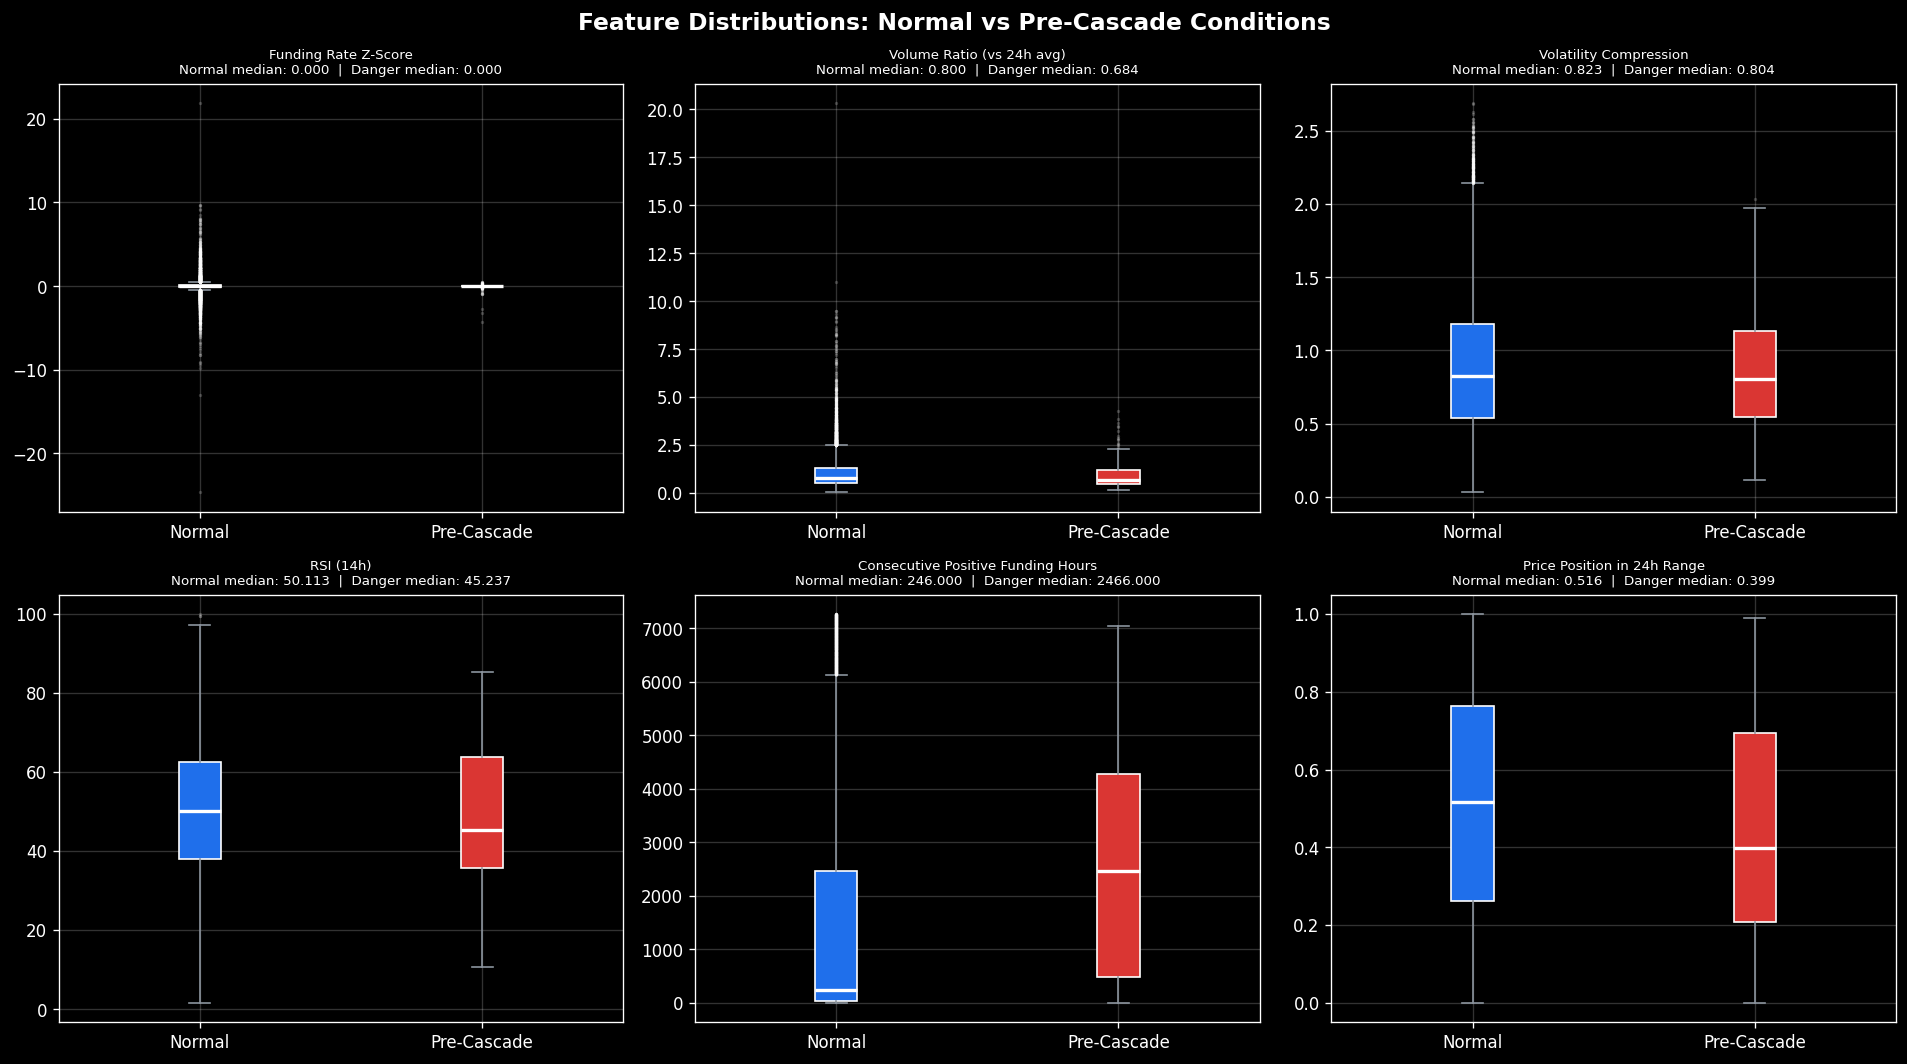

✅ Saved to docs/plot_feature_distributions.png


In [5]:
# Cell 4: Box plots — Normal vs Pre-Cascade for key features
# CONCEPT: If the red box (pre-cascade) sits in a different position
# than the blue box (normal), that feature has predictive power.
# The more separation between boxes, the more useful the feature is.

features_to_plot = [
    ("funding_zscore",               "Funding Rate Z-Score"),
    ("volume_ratio",                 "Volume Ratio (vs 24h avg)"),
    ("volatility_compression",       "Volatility Compression"),
    ("rsi_14",                       "RSI (14h)"),
    ("consecutive_positive_funding", "Consecutive Positive Funding Hours"),
    ("price_position",               "Price Position in 24h Range"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Feature Distributions: Normal vs Pre-Cascade Conditions",
             fontsize=14, fontweight="bold")

for ax, (feat, label) in zip(axes.flatten(), features_to_plot):
    n_vals = normal[feat].dropna()
    d_vals = danger[feat].dropna()

    bp = ax.boxplot(
        [n_vals, d_vals],
        labels=["Normal", "Pre-Cascade"],
        patch_artist=True,
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(color="#8b949e"),
        capprops=dict(color="#8b949e"),
        flierprops=dict(marker=".", color="#8b949e", alpha=0.2, markersize=2),
    )

    # Blue = normal market, Red = pre-cascade danger
    bp["boxes"][0].set_facecolor("#1f6feb")
    bp["boxes"][1].set_facecolor("#da3633")

    # Print the median values so we can read the difference precisely
    med_normal = n_vals.median()
    med_danger = d_vals.median()
    ax.set_title(f"{label}\nNormal median: {med_normal:.3f}  |  Danger median: {med_danger:.3f}",
                 fontsize=8, pad=6)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("docs/plot_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved to docs/plot_feature_distributions.png")

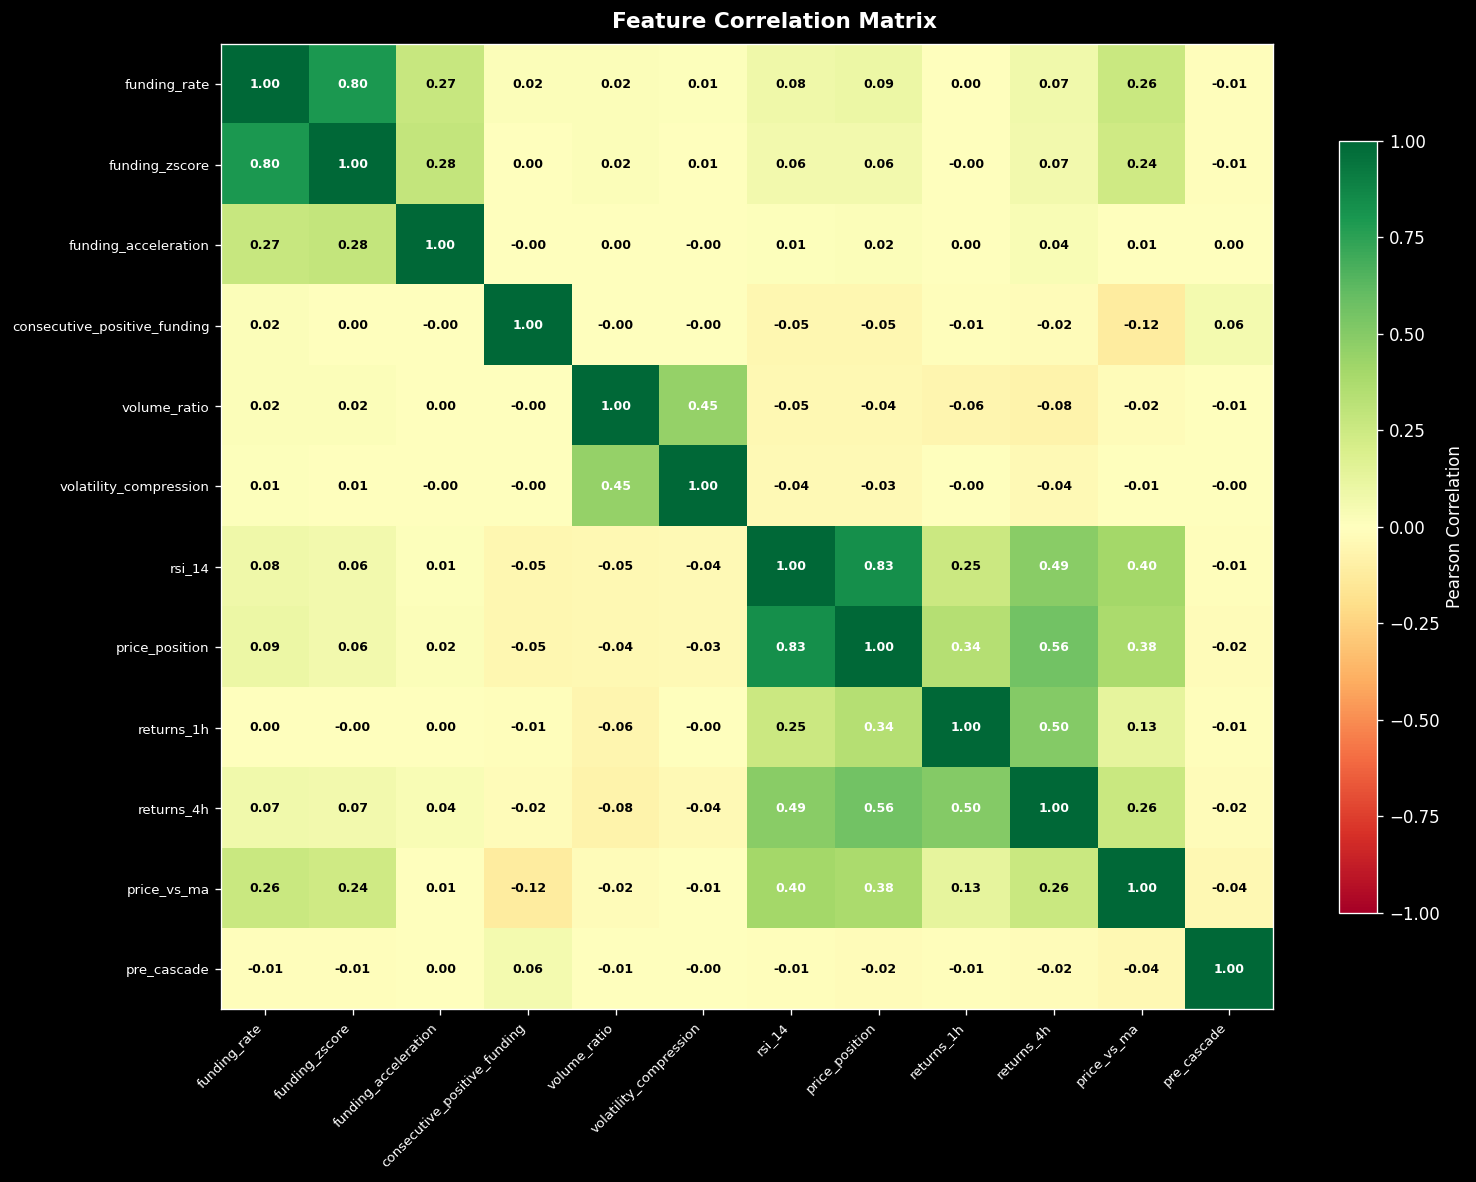

Feature correlations with pre_cascade (ranked)
consecutive_positive_funding        +0.0577  ██
price_vs_ma                         -0.0409  █
price_position                      -0.0220  
returns_4h                          -0.0181  
returns_1h                          -0.0128  
funding_rate                        -0.0128  
funding_zscore                      -0.0089  
rsi_14                              -0.0088  
volume_ratio                        -0.0077  
volatility_compression              -0.0047  
funding_acceleration                +0.0045  


In [8]:
# Cell 5 (final): Correlation heatmap — green theme with readable text
# FIX: Use black text on light cells, white text on dark cells
# The threshold 0.3 is the cutoff — cells with abs correlation
# above 0.3 are dark green and get white text, below get black text.

feature_cols = [
    "funding_rate", "funding_zscore", "funding_acceleration",
    "consecutive_positive_funding", "volume_ratio",
    "volatility_compression", "rsi_14", "price_position",
    "returns_1h", "returns_4h", "price_vs_ma", "pre_cascade"
]

corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
fig.suptitle("Feature Correlation Matrix", fontsize=13, fontweight="bold")

im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(feature_cols, fontsize=8)

for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        val = corr.values[i, j]
        # Light yellow cells (low correlation) get black text
        # Dark green/red cells (high correlation) get white text
        text_color = "white" if abs(val) >= 0.3 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7.5, color=text_color, fontweight="bold")

plt.colorbar(im, ax=ax, shrink=0.8, label="Pearson Correlation")
plt.tight_layout()
plt.savefig("docs/plot_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Ranked correlations with pre_cascade
print("=" * 45)
print("Feature correlations with pre_cascade (ranked)")
print("=" * 45)
corr_ranked = corr["pre_cascade"].drop("pre_cascade").sort_values(
    key=abs, ascending=False
)
for feat, val in corr_ranked.items():
    bar = "█" * int(abs(val) * 40)
    direction = "+" if val > 0 else "-"
    print(f"{feat:<35} {direction}{abs(val):.4f}  {bar}")

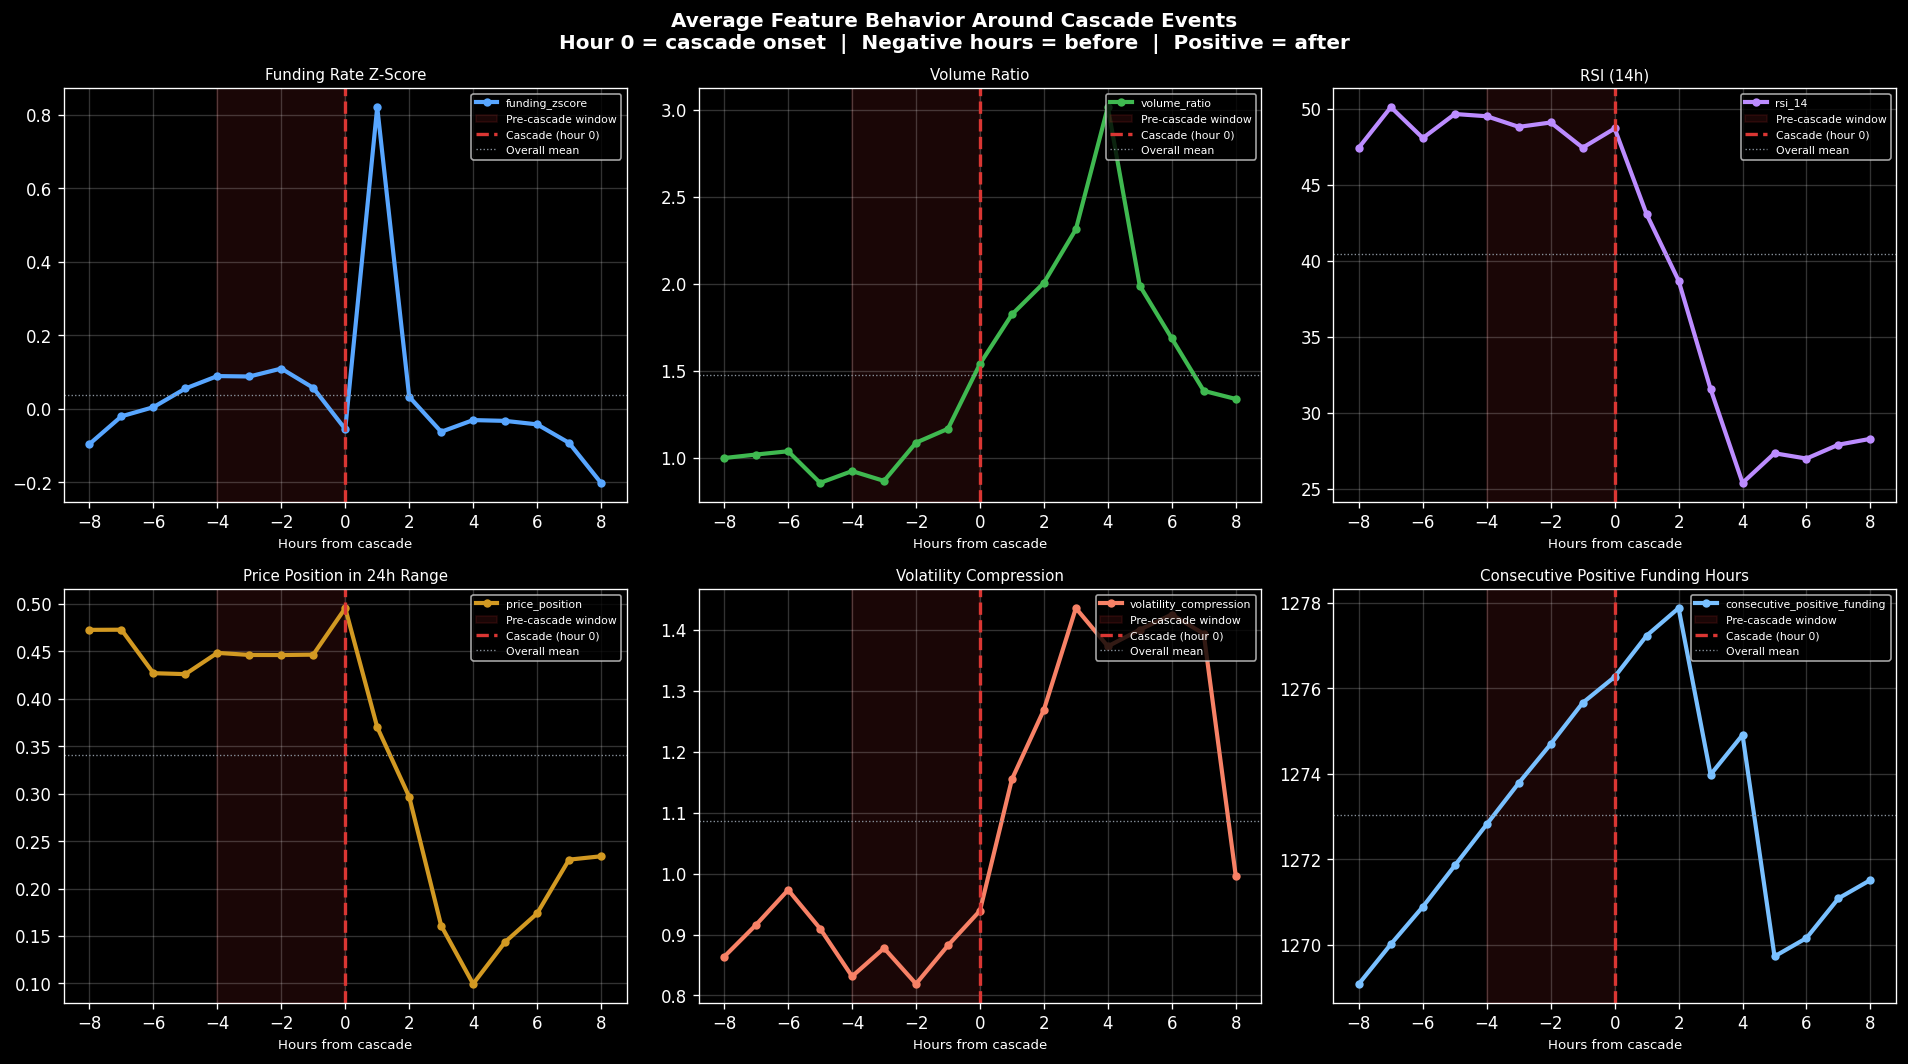

✅ Saved to docs/plot_cascade_fingerprint.png


In [9]:
# Cell 6: Average feature behavior around cascade events
# CONCEPT: "Event study analysis" — standard technique in quantitative finance.
# For every cascade event, we grab the 8 hours before and after,
# then average across ALL events. This reveals the typical fingerprint
# of conditions leading into a crash — even if no single event is identical.

cascade_times = df[df["cascade_event"] == 1].index
WINDOW = 8  # hours before and after to capture

records = []

for t in cascade_times:
    # Get the symbol for this cascade
    row_at_t = df.loc[t]
    sym = row_at_t["symbol"] if isinstance(row_at_t["symbol"], str) \
          else row_at_t["symbol"].iloc[0]

    sym_df = df[df["symbol"] == sym]

    for h in range(-WINDOW, WINDOW + 1):
        target = t + pd.Timedelta(f"{h}h")
        if target in sym_df.index:
            row = sym_df.loc[target]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[0]
            records.append({
                "hours_from_cascade":     h,
                "funding_zscore":         row["funding_zscore"],
                "volume_ratio":           row["volume_ratio"],
                "rsi_14":                 row["rsi_14"],
                "price_position":         row["price_position"],
                "volatility_compression": row["volatility_compression"],
                "consecutive_positive_funding": row["consecutive_positive_funding"],
            })

event_df = pd.DataFrame(records)

# groupby + mean = average value of each feature at each hour offset
# This smooths out noise across all 56 events into one clean signal
avg = event_df.groupby("hours_from_cascade").mean()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    "Average Feature Behavior Around Cascade Events\n"
    "Hour 0 = cascade onset  |  Negative hours = before  |  Positive = after",
    fontsize=12, fontweight="bold"
)

plot_config = [
    ("funding_zscore",               "Funding Rate Z-Score",              "#58a6ff"),
    ("volume_ratio",                 "Volume Ratio",                      "#3fb950"),
    ("rsi_14",                       "RSI (14h)",                         "#bc8cff"),
    ("price_position",               "Price Position in 24h Range",       "#d29922"),
    ("volatility_compression",       "Volatility Compression",            "#f78166"),
    ("consecutive_positive_funding", "Consecutive Positive Funding Hours","#79c0ff"),
]

for ax, (feat, label, color) in zip(axes.flatten(), plot_config):
    ax.plot(avg.index, avg[feat], color=color, linewidth=2.5,
            marker="o", markersize=4, label=feat)

    # Shade the pre-cascade warning window (4 hours before cascade)
    ax.axvspan(-4, 0, alpha=0.12, color="#da3633", label="Pre-cascade window")

    # Mark the cascade moment
    ax.axvline(0, color="#da3633", linewidth=2, linestyle="--", label="Cascade (hour 0)")

    # Draw the overall mean as a reference line
    ax.axhline(avg[feat].mean(), color="#8b949e", linewidth=0.8,
               linestyle=":", label="Overall mean")

    ax.set_title(label, fontsize=9, pad=5)
    ax.set_xlabel("Hours from cascade", fontsize=8)
    ax.legend(fontsize=6.5, loc="upper right")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("docs/plot_cascade_fingerprint.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved to docs/plot_cascade_fingerprint.png")